In [1]:
import pandas as pd

df = pd.read_excel('/content/drive/MyDrive/Exploratory data/salary.xlsx')
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28,Female,Master's,Data Analyst,3.0,65000.0
2,45,Male,PhD,Senior Manager,NaN,150000.0
3,36,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52,Male,Master's,Director,20.0,200000.0


In [2]:
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Hitung statistik deskriptif, median, modus, simpangan rata-rata, range, dan variansi
descriptive_stats = numerical_df.describe()
median_values = numerical_df.median()
mode_values = numerical_df.mode().iloc[0]
mad_values = numerical_df.apply(lambda x: (x - x.mean()).abs().mean())
range_values = numerical_df.max() - numerical_df.min()
variance_values = numerical_df.var()

descriptive_stats.loc['median'] = median_values
descriptive_stats.loc['mode'] = mode_values
descriptive_stats.loc['mad'] = mad_values
descriptive_stats.loc['range'] = range_values
descriptive_stats.loc['variance'] = variance_values

print("Ringkasan Statistik Deskriptif:")
display(descriptive_stats)

Ringkasan Statistik Deskriptif:


,Age,Years of Experience,Salary
count,6707.000000,6705.000000,6.703000e+03
mean,33.623677,8.096346,1.154461e+05
std,7.621529,6.067248,5.388179e+04
min,21.000000,0.000000,3.500000e+02
25%,28.000000,3.000000,7.000000e+04
50%,32.000000,7.000000,1.150000e+05
75%,38.000000,12.000000,1.600000e+05
max,62.000000,35.000000,1.000000e+06
median,32.000000,7.000000,1.150000e+05
mode,27.000000,2.000000,1.400000e+05


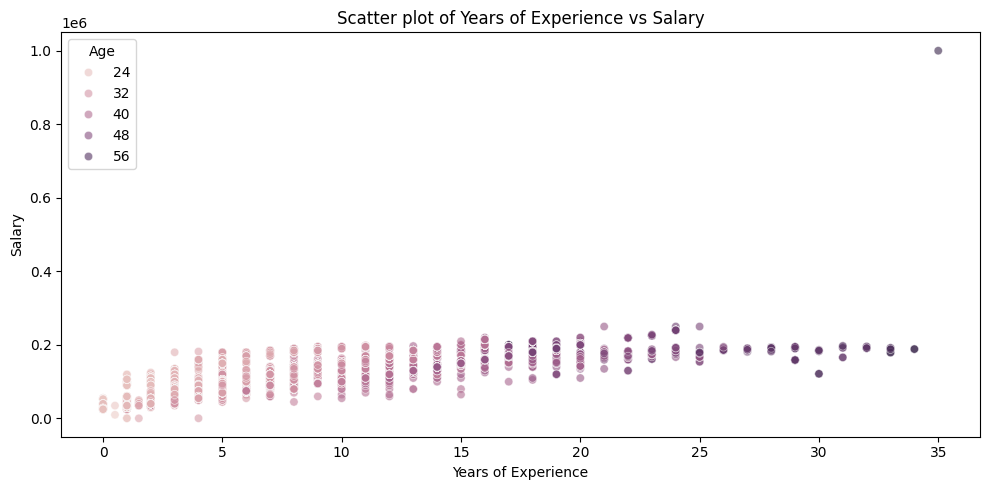

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contoh Visualisasi hubungan antar dua kolom numerik (Scatter Plot)
# Kita bisa memilih kolom yang relevan, misalnya Lama bekera vs Gaji, diwarnai berdasarkan 'Usia'
numerical_cols_scatter = ['Years of Experience', 'Salary']
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x=numerical_cols_scatter[0], y=numerical_cols_scatter[1], hue='Age', alpha=0.6)
plt.title(f'Scatter plot of {numerical_cols_scatter[0]} vs {numerical_cols_scatter[1]}')
plt.xlabel(numerical_cols_scatter[0])
plt.ylabel(numerical_cols_scatter[1])
plt.tight_layout()
plt.show()

In [8]:
df = df.reset_index(drop=True)
df.index = df.index + 1

df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
1,32,Male,Bachelor's,Software Engineer,5.0,90000.0
2,28,Female,Master's,Data Analyst,3.0,65000.0
3,45,Male,PhD,Senior Manager,NaN,150000.0
4,36,Female,Bachelor's,Sales Associate,7.0,60000.0
5,52,Male,Master's,Director,20.0,200000.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6707 entries, 1 to 6707
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6707 non-null   int64  
 1   Gender               6707 non-null   object 
 2   Education Level      6706 non-null   object 
 3   Job Title            6706 non-null   object 
 4   Years of Experience  6705 non-null   float64
 5   Salary               6703 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 314.5+ KB


In [10]:
print(df.isnull().sum())

Age                    0
Gender                 0
Education Level        1
Job Title              1
Years of Experience    2
Salary                 4
dtype: int64


In [23]:
# Menentukan modus dari kolom 'Salary'
Salary_mode = df['Salary'].mode()[0]
print(f"Modus dari kolom 'Salary': {Salary_mode}")

# Mengisi nilai yang hilang di kolom 'Salary' dengan modus
df['Salary'] = df['Salary'].fillna(Salary_mode)

# Verifikasi bahwa tidak ada lagi nilai yang hilang di kolom 'Salary'
missing_values_after_fill = df['Salary'].isnull().sum()
print(f"\nJumlah nilai yang hilang di kolom 'Salary' setelah pengisian: {missing_values_after_fill}")

Modus dari kolom 'Salary': 120000.0

Jumlah nilai yang hilang di kolom 'Salary' setelah pengisian: 0


/tmp/ipython-input-2389023489.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Salary'] = df['Salary'].fillna(Salary_mode)


In [17]:
# Hitung jumlah baris duplikat
duplicate_rows_count = df.duplicated().sum()

# Cetak jumlah baris duplikat
print(f"Jumlah baris duplikat: {duplicate_rows_count}")

# Jika ada baris duplikat, hapus baris duplikat
if duplicate_rows_count > 0:
    print("\nMenghapus baris duplikat...")
    df = df.drop_duplicates()
    print("Baris duplikat telah dihapus.")

# Verifikasi bahwa tidak ada lagi baris duplikat
duplicate_rows_count_after = df.duplicated().sum()
print(f"\nJumlah baris duplikat setelah penghapusan: {duplicate_rows_count_after}")

# Tampilkan beberapa baris pertama DataFrame setelah penghapusan duplikat
if duplicate_rows_count > 0:
    print("\nBeberapa baris pertama DataFrame setelah penghapusan duplikat:")
    display(df.head())

Jumlah baris duplikat: 0

Jumlah baris duplikat setelah penghapusan: 0


In [18]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
1,32,Male,Bachelor's,Software Engineer,5.0,90000.0
2,28,Female,Master's,Data Analyst,3.0,65000.0
3,45,Male,PhD,Senior Manager,NaN,150000.0
4,36,Female,Bachelor's,Sales Associate,7.0,60000.0
5,52,Male,Master's,Director,20.0,200000.0


In [24]:
# Identifikasi kolom kategorikal
categorical_cols = df.select_dtypes(include='object').columns

print("Memeriksa nilai unik dan distribusi untuk kolom kategorikal:")
for col in categorical_cols:
    print(f"\nKolom: {col}")
    print(df[col].value_counts())

# Identifikasi kolom numerik
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("\nMemeriksa statistik deskriptif untuk kolom numerik:")
display(df[numerical_cols].describe())

Memeriksa nilai unik dan distribusi untuk kolom kategorikal:

Kolom: Gender
Gender
Male      971
Female    816
Other       7
Name: count, dtype: int64

Kolom: Education Level
Education Level
Bachelor's Degree    508
Master's Degree      447
PhD                  342
Bachelor's           263
Master's             122
High School          110
phD                    1
Name: count, dtype: int64

Kolom: Job Title
Job Title
software engineer manager    127
full stack engineer          123
senior software engineer      96
senior project engineer       95
back end developer            81
                            ... 
developer                      1
social m                       1
social media man               1
delivery driver                1
intern                         1
Name: count, Length: 193, dtype: int64

Memeriksa statistik deskriptif untuk kolom numerik:


,Age,Years of Experience,Salary
count,1794.000000,1792.000000,1794.000000
mean,35.140468,9.162109,113682.267001
std,8.232829,6.866281,55634.391857
min,21.000000,0.000000,350.000000
25%,29.000000,3.000000,70000.000000
50%,33.000000,8.000000,110353.500000
75%,41.000000,13.000000,160000.000000
max,62.000000,35.000000,1000000.000000


/tmp/ipython-input-39722601.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Job Title'] = df['Job Title'].str.lower().str.strip()



Distribusi kolom 'Job Title' setelah standardisasi:
Job Title
software engineer manager    127
full stack engineer          123
senior software engineer      96
senior project engineer       95
back end developer            81
                            ... 
developer                      1
social m                       1
social media man               1
delivery driver                1
intern                         1
Name: count, Length: 193, dtype: int64


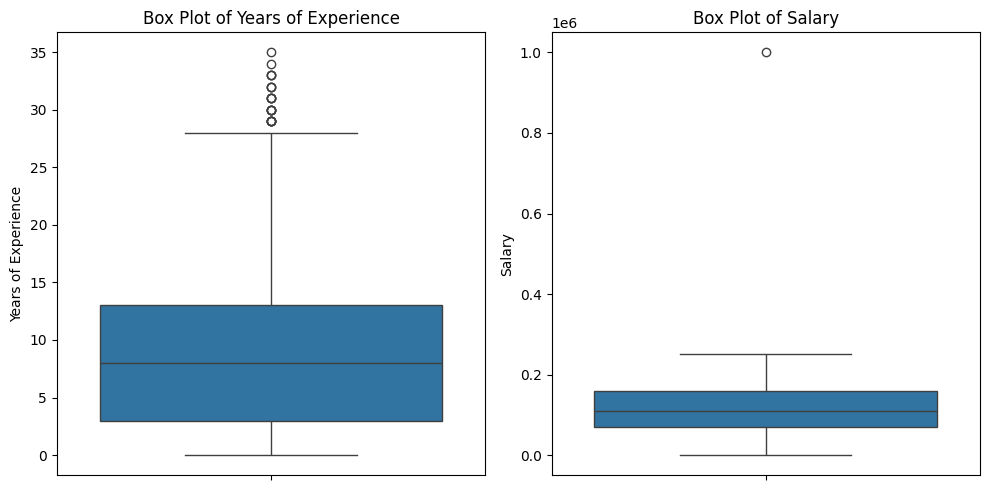

In [25]:
# Standardisasi kolom 'Job Title'
df['Job Title'] = df['Job Title'].str.lower().str.strip()

# Verifikasi setelah standardisasi
print("\nDistribusi kolom 'Job Title' setelah standardisasi:")
print(df['Job Title'].value_counts())

import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi kolom numerik untuk mendeteksi outlier (Box Plot)
numerical_cols_outliers = ['Years of Experience', 'Salary']
plt.figure(figsize=(10, 5))
for i, col in enumerate(numerical_cols_outliers):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(data=df, y=col)
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()


Statistik deskriptif untuk 'Salary' setelah capping (upper limit = 20000000):


/tmp/ipython-input-2081740269.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Salary'] = df['Salary'].clip(upper=upper_limit)


,Salary
count,1790.000000
mean,113668.149162
std,55695.750262
min,350.000000
25%,70000.000000
50%,110000.000000
75%,160000.000000
max,1000000.000000


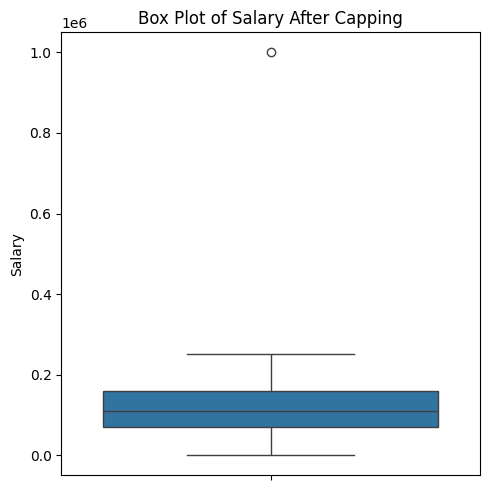

In [22]:
# Handle outliers in 'pendapatan' using capping
# Determine a reasonable upper limit (e.g., based on the 95th percentile or visual inspection)
# From the describe output, the max is 8.6e7, while 75% is around 1.6e7.
# Let's cap at a value slightly above the 75th percentile, e.g., 30,000,000.
upper_limit = 20000000
df['Salary'] = df['Salary'].clip(upper=upper_limit)

print(f"\nStatistik deskriptif untuk 'Salary' setelah capping (upper limit = {upper_limit}):")
display(df['Salary'].describe())

# Visualisasi 'Salary' setelah capping (Box Plot)
plt.figure(figsize=(5, 5))
sns.boxplot(data=df, y='Salary')
plt.title('Box Plot of Salary After Capping')
plt.ylabel('Salary')
plt.tight_layout()
plt.show()

In [27]:
# Hitung jumlah nilai yang hilang di kolom 'Salary' sebelum penghapusan
missing_values_before_drop = df['Salary'].isnull().sum()
print(f"Jumlah nilai yang hilang di kolom 'Salary' sebelum penghapusan: {missing_values_before_drop}")

# Hapus baris dengan nilai yang hilang di kolom 'Salary'
df_dropped = df.dropna(subset=['Salary']).copy()

# Verifikasi bahwa tidak ada lagi nilai yang hilang di kolom 'Salary'
missing_values_after_drop = df_dropped['Salary'].isnull().sum()
print(f"\nJumlah nilai yang hilang di kolom 'Salary' setelah penghapusan: {missing_values_after_drop}")

# Tampilkan beberapa baris pertama DataFrame setelah penghapusan
print("\nBeberapa baris pertama DataFrame setelah penghapusan nilai yang hilang:")
display(df_dropped.head())

print(f"\nUkuran DataFrame setelah penghapusan nilai yang hilang: {df_dropped.shape}")

Jumlah nilai yang hilang di kolom 'Salary' sebelum penghapusan: 0

Jumlah nilai yang hilang di kolom 'Salary' setelah penghapusan: 0

Beberapa baris pertama DataFrame setelah penghapusan nilai yang hilang:


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
1,32,Male,Bachelor's,software engineer,5.0,90000.0
2,28,Female,Master's,data analyst,3.0,65000.0
3,45,Male,PhD,senior manager,NaN,150000.0
4,36,Female,Bachelor's,sales associate,7.0,60000.0
5,52,Male,Master's,director,20.0,200000.0



Ukuran DataFrame setelah penghapusan nilai yang hilang: (1794, 6)


In [28]:
# Tentukan batas atas untuk outlier (sesuai dengan yang Anda gunakan sebelumnya)
upper_limit = 20000000

# Hitung jumlah baris sebelum penghapusan outlier
rows_before_drop = len(df)
print(f"Jumlah baris sebelum menghapus outlier: {rows_before_drop}")

# Hapus baris di mana 'Years of Experience' lebih besar dari batas atas
df_no_outliers = df[df['Years of Experience'] <= upper_limit].copy()

# Hitung jumlah baris setelah penghapusan outlier
rows_after_drop = len(df_no_outliers)
print(f"Jumlah baris setelah menghapus outlier di 'Years of Experience': {rows_after_drop}")
print(f"Jumlah outlier yang dihapus: {rows_before_drop - rows_after_drop}")

# Tampilkan statistik deskriptif untuk 'Years of Experience' setelah penghapusan outlier
print("\nStatistik deskriptif untuk 'Years of Experience' setelah menghapus outlier:")
display(df_no_outliers['Years of Experience'].describe())

# Tampilkan beberapa baris pertama DataFrame setelah penghapusan outlier
print("\nBeberapa baris pertama DataFrame setelah menghapus outlier:")
display(df_no_outliers.head())


Jumlah baris sebelum menghapus outlier: 1794
Jumlah baris setelah menghapus outlier di 'Years of Experience': 1792
Jumlah outlier yang dihapus: 2

Statistik deskriptif untuk 'Years of Experience' setelah menghapus outlier:


,Years of Experience
count,1792.000000
mean,9.162109
std,6.866281
min,0.000000
25%,3.000000
50%,8.000000
75%,13.000000
max,35.000000



Beberapa baris pertama DataFrame setelah menghapus outlier:


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
1,32,Male,Bachelor's,software engineer,5.0,90000.0
2,28,Female,Master's,data analyst,3.0,65000.0
4,36,Female,Bachelor's,sales associate,7.0,60000.0
5,52,Male,Master's,director,20.0,200000.0
6,29,Male,Bachelor's,marketing analyst,2.0,120000.0


In [30]:
output_file_name = 'salary.xlsx'
df.to_excel(output_file_name, index=False)

print(f"DataFrame telah berhasil disimpan ke '{output_file_name}'")

DataFrame telah berhasil disimpan ke 'salary.xlsx'


In [31]:
correlation = df['Years of Experience'].corr(df['Salary'])
print(f"Korelasi antara Lama bekerja dan Pendapatan: {correlation}")

# Hitung koefisien determinasi (R-squared)
r_squared = correlation ** 2
print(f"Koefisien determinasi (R-squared) antara Lama bekerja dan Pendapatan: {r_squared}")

Korelasi antara Lama bekerja dan Pendapatan: 0.7886003718220979
Koefisien determinasi (R-squared) antara Lama bekerja dan Pendapatan: 0.6218905464379509


In [41]:
# Rename the column to remove the space
df = df.rename(columns={'Years of Experience': 'Years_of_Experience'})

# Verify the column name has been changed
print(df.columns)

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years_of_Experience',
       'Salary'],
      dtype='object')


In [43]:
import statsmodels.formula.api as smf
# definisikan dan sesuaikan model regresi years of experience vs salary
model_yoe_salary = smf.ols('Years_of_Experience ~ Salary', data=df).fit()

# mengambil koefisien dari model regresi years of experience vs salary
intercept_yoe_salary = model_yoe_salary.params['Intercept']
yoe_coef_yoe_salary = model_yoe_salary.params['Salary']

# mengambil jumlah kuadrat residual (ssr) dari model baru
ssr_yoe_salary = model_yoe_salary.ssr

# tampilkan ringkasan model
print(f"jumlah kuadrat residual (ssr) untuk model years of experience vs salary: {ssr_yoe_salary:.4f}")
print(f"persamaan garis regresi (years of experience vs salary):")
print(f"Years of Experience prediksi = {intercept_yoe_salary:.4f} + {yoe_coef_yoe_salary:.4f} * Years_of_Experience")

jumlah kuadrat residual (ssr) untuk model years of experience vs salary: 31926.8655
persamaan garis regresi (years of experience vs salary):
Years of Experience prediksi = -1.8952 + 0.0001 * Years_of_Experience


Hasil Uji Shapiro-Wilk: statistik = 0.8801, p-value = 0.0000
Data tidak berdistribusi normal (menolak H0)


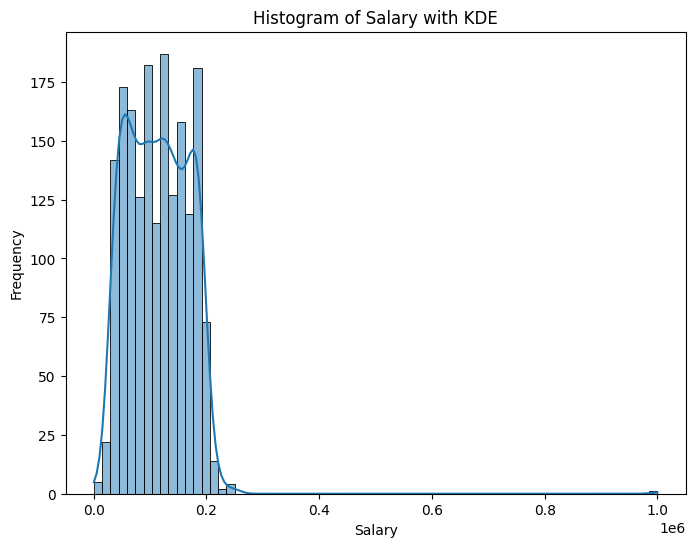

In [44]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

shapiro_test = stats.shapiro(df['Salary'])
print(f"Hasil Uji Shapiro-Wilk: statistik = {shapiro_test.statistic:.4f}, p-value = {shapiro_test.pvalue:.4f}")
alpha = 0.05
if shapiro_test.pvalue > alpha:
    print("Data kemungkinan berdistribusi normal (gagal menolak H0)")
else:
    print("Data tidak berdistribusi normal (menolak H0)")

plt.figure(figsize=(8, 6))
sns.histplot(df['Salary'], kde=True)
plt.title("Histogram of Salary with KDE")
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()